# Combine scenarios in one figure

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 12,
})
from matplotlib.ticker import FuncFormatter
from IPython.display import Image, display
import xarray as xr
from functions import read_netCDF_xr


# Uncomment for interactive plots:
%matplotlib widget 

### Parameters

In [2]:
# Choose the language for figures (FR or EN)
lang='FR'

cm=1/2.54 # centimeters in inches

savefig=False # To save figures

C_thresh=0.1 # [ug/l]

### Load the data from all scenarios

In [ ]:
data_constant=read_netCDF_xr(os.path.join("Results","constant_scenario_splitted_inflow.nc"))
data_periodic=read_netCDF_xr(os.path.join("Results","periodic_scenario_splitted_inflow.nc"))
data_simulations=read_netCDF_xr(os.path.join("Results","simulations_splitted_inflow.nc"))

### Compute average and std for the Monte-Carlo simulations

In [4]:
hepi_sim_mean=data_simulations.hepi.mean(dim="simulation")
hepi_sim_std=data_simulations.hepi.std(dim="simulation")
Cepi_sim_mean=data_simulations.Cepi.mean(dim="simulation")
Cepi_sim_std=data_simulations.Cepi.std(dim="simulation")
Chypo_sim_mean=data_simulations.Chypo.mean(dim="simulation")
Chypo_sim_std=data_simulations.Chypo.std(dim="simulation")
Qepi_sim_mean=data_simulations.Qepi.mean(dim="simulation")
Qhypo_sim_mean=data_simulations.Qhypo.mean(dim="simulation")
Vepi_sim_mean=data_simulations.Vepi.mean(dim="simulation")
Vhypo_sim_mean=data_simulations.Vhypo.mean(dim="simulation")


### Compute critical times

In [5]:
tcrit_epi={"constant":data_constant.time.values[np.where(data_constant.Cepi[0,:].to_numpy()<=C_thresh)[0][0]],
            "periodic":data_periodic.time.values[np.where(data_periodic.Cepi[0,:].to_numpy()<=C_thresh)[0][0]],
            "simulations":data_simulations.time.values[np.where(Cepi_sim_mean.to_numpy()<=C_thresh)[0][0]]}
tcrit_hypo={"constant":data_constant.time.values[np.where(data_constant.Chypo[0,:].to_numpy()<=C_thresh)[0][0]],
            "periodic":data_periodic.time.values[np.where(data_periodic.Chypo[0,:].to_numpy()<=C_thresh)[0][0]],
            "simulations":data_simulations.time.values[np.where(Chypo_sim_mean.to_numpy()<=C_thresh)[0][0]]}


### Figure layer residence time 

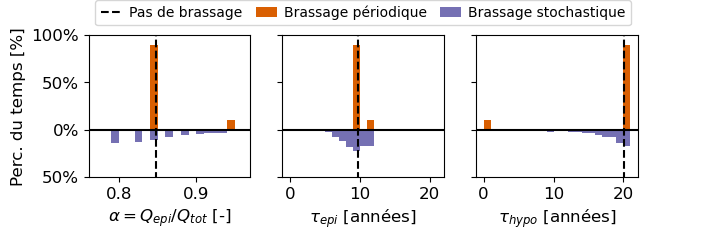

In [6]:
fig,ax=plt.subplots(1,3,figsize=(18*cm,6*cm),sharey=True)
cmap=plt.get_cmap("Dark2")
bin_edges = np.arange(0.77, 0.97, 0.01)
bin_edges_time=np.arange(0, 22, 1)
weights_1sim=np.ones(len(data_simulations.time))/len(data_simulations.time)*100
weights_allsim=np.ones(len(data_simulations.Qepi.values.flatten()))/len(data_simulations.Qepi.values.flatten())*100
if lang=='FR':
    lab_scenarios=["Pas de brassage","Brassage périodique","Brassage stochastique"]
else:
    lab_scenarios=["No mixing","Periodic mixing","Stochastic mixing"]

ax[0].plot(np.mean((data_constant.Qepi[0,:]/(data_constant.Qepi[0,:]+data_constant.Qhypo[0,:])).values)*np.ones(2),[-100,100],'k--')
ax[0].hist(data_periodic.Qepi[0,:]/(data_periodic.Qepi[0,:]+data_periodic.Qhypo[0,:]),bins=bin_edges,color=cmap(1),weights=weights_1sim)
#ax[0].hist(Qepi_sim_mean/(Qepi_sim_mean+Qhypo_sim_mean),bins=bin_edges,color=cmap(2))
ax[0].hist((data_simulations.Qepi/(data_simulations.Qepi+data_simulations.Qhypo)).values.flatten(),bins=bin_edges,color=cmap(2),weights=-weights_allsim)
xlimval=ax[0].get_xlim()
ax[0].plot(xlimval,[0,0],'-k')
ax[0].set_xlim(xlimval)
ax[0].set_xlabel('$\\alpha=Q_{{epi}}/Q_{{tot}}$ [-]')
if lang=="FR":
    ax[0].set_ylabel('Perc. du temps [%]')
else:
    ax[0].set_ylabel('Perc. of time [%]')
ax[0].set_ylim(-50,100)
ax[0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{abs(x):.0f}%")
)

ax[1].plot(np.mean((data_constant.Vepi[0,:]/data_constant.Qepi[0,:]/(86400*365)).values)*np.ones(2),[-100,100],'k--',label=lab_scenarios[0])
ax[1].hist(data_periodic.Vepi[0,:]/data_periodic.Qepi[0,:]/(86400*365),bins=bin_edges_time,color=cmap(1),label=lab_scenarios[1],weights=weights_1sim)
#ax[1].hist(Vepi_sim_mean/Qepi_sim_mean/(86400*365),bins=bin_edges_time,color=cmap(2),label=lab_scenarios[2])
ax[1].hist((data_simulations.Vepi/(data_simulations.Qepi*86400*365)).values.flatten(),bins=bin_edges_time,color=cmap(2),label=lab_scenarios[2],weights=-weights_allsim)
xlimval=ax[1].get_xlim()
ax[1].plot(xlimval,[0,0],'-k')
ax[1].set_xlim(xlimval)
if lang=="FR":
    ax[1].set_xlabel('$\\tau_{epi}$ [années]')
else:
    ax[1].set_xlabel('$\\tau_{epi}$ [yr]')
ax[1].legend(loc="lower center",bbox_to_anchor=(0.5, 1.02),ncol=3,fontsize=10,columnspacing=1.0,handletextpad=0.5, handlelength=1.5)

ax[2].plot(np.mean((data_constant.Vhypo[0,:]/data_constant.Qhypo[0,:]/(86400*365)).values)*np.ones(2),[-100,100],'k--')
ax[2].hist(data_periodic.Vhypo[0,:]/data_periodic.Qhypo[0,:]/(86400*365),bins=bin_edges_time,color=cmap(1),weights=weights_1sim)
#ax[2].hist(Vhypo_sim_mean/Qhypo_sim_mean/(86400*365),bins=bin_edges_time,color=cmap(2))
ax[2].hist((data_simulations.Vhypo/(data_simulations.Qhypo*86400*365)).values.flatten(),bins=bin_edges_time,color=cmap(2),weights=-weights_allsim)
xlimval=ax[2].get_xlim()
ax[2].plot(xlimval,[0,0],'-k')
ax[2].set_xlim(xlimval)
if lang=="FR":
    ax[2].set_xlabel('$\\tau_{hypo}$ [années]')
else:
    ax[2].set_xlabel('$\\tau_{hypo}$ [yr]')

fig.subplots_adjust(bottom=0.25,top=1-0.15)

In [7]:
if savefig:
    fig.savefig(os.path.join("Figures","layer_residence_time.png"),dpi=400)
    print("Figure saved!")

### Figure time series

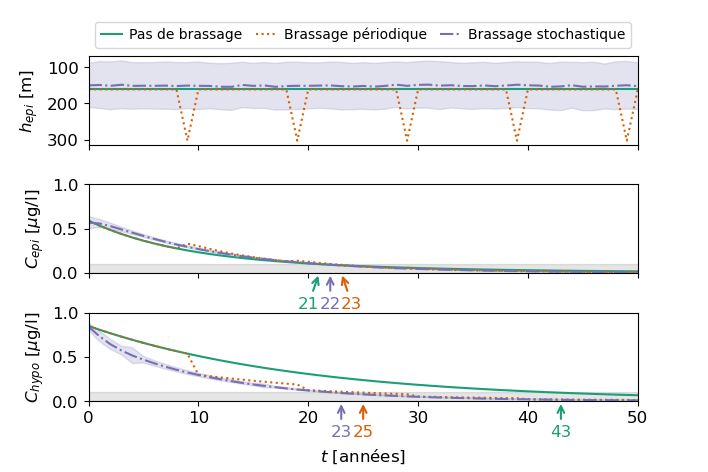

In [8]:
fig,ax=plt.subplots(3,1,figsize=(18*cm,12*cm),sharex=True)
cmap=plt.get_cmap("Dark2")
if lang=='FR':
    lab_scenarios=["Pas de brassage","Brassage périodique","Brassage stochastique"]
else:
    lab_scenarios=["No mixing","Periodic mixing","Stochastic mixing"]

ax[0].plot(data_constant.time,data_constant.hepi[0,:],color=cmap(0),linestyle='-',label=lab_scenarios[0])
ax[0].plot(data_periodic.time,data_periodic.hepi[0,:],color=cmap(1),linestyle=':',label=lab_scenarios[1])
ax[0].plot(data_simulations.time,hepi_sim_mean,linestyle='-.',color=cmap(2),label=lab_scenarios[2])
ax[0].fill_between(x=data_simulations.time,y1=hepi_sim_mean-hepi_sim_std,y2=hepi_sim_mean+hepi_sim_std,linestyle='-',color=cmap(2),alpha=0.2)
ax[0].set_ylabel("$h_{epi}$ [m]")
ax[0].legend(loc="lower center",bbox_to_anchor=(0.5, 1.02),ncol=3,fontsize=10,columnspacing=1.0,handletextpad=0.5, handlelength=1.5)
ax[0].invert_yaxis()

ax[1].plot(data_constant.time,data_constant.Cepi[0,:],color=cmap(0),linestyle='-',label=lab_scenarios[0])
ax[1].plot(data_periodic.time,data_periodic.Cepi[0,:],color=cmap(1),linestyle=':',label=lab_scenarios[1])
ax[1].plot(data_simulations.time,Cepi_sim_mean,linestyle='-.',color=cmap(2),label=lab_scenarios[2])
ax[1].fill_between(x=data_simulations.time,y1=Cepi_sim_mean-Cepi_sim_std,y2=Cepi_sim_mean+Cepi_sim_std,linestyle='-',color=cmap(2),alpha=0.2)
ax[1].axhspan(0, C_thresh, color='k', alpha=0.1)
ax[1].annotate(str(int(tcrit_epi["constant"])),xy=(tcrit_epi["constant"], 0),
               xytext=(tcrit_epi["constant"], -0.4),ha="right",color=cmap(0),
               arrowprops=dict(arrowstyle="->",color=cmap(0),lw=1.5))
# ax[1].text(tcrit_epi["constant"],-0.4,str(int(tcrit_epi["constant"])),ha="right",color=cmap(0))
ax[1].annotate(str(int(tcrit_epi["periodic"])),xy=(tcrit_epi["periodic"], 0),
               xytext=(tcrit_epi["periodic"], -0.4),ha="left",color=cmap(1),
               arrowprops=dict(arrowstyle="->",color=cmap(1),lw=1.5))
# ax[1].text(tcrit_epi["periodic"],-0.4,str(int(tcrit_epi["periodic"])),ha="left",color=cmap(1))
ax[1].annotate(str(int(tcrit_epi["simulations"])),xy=(tcrit_epi["simulations"], 0),
               xytext=(tcrit_epi["simulations"], -0.4),ha="center",color=cmap(2),
               arrowprops=dict(arrowstyle="->",color=cmap(2),lw=1.5))
ax[1].set_ylim([0,1])
ax[1].set_ylabel("$C_{epi}$ [$\mu$g/l]")
#ax[1].legend(bbox_to_anchor=(1,0.5),loc="center left")

ax[2].plot(data_constant.time,data_constant.Chypo[0,:],color=cmap(0),linestyle='-',label=lab_scenarios[0])
ax[2].plot(data_periodic.time,data_periodic.Chypo[0,:],color=cmap(1),linestyle=':',label=lab_scenarios[1])
ax[2].plot(data_simulations.time,Chypo_sim_mean,linestyle='-.',color=cmap(2),label=lab_scenarios[2])
ax[2].fill_between(x=data_simulations.time,y1=Chypo_sim_mean-Chypo_sim_std,y2=Chypo_sim_mean+Chypo_sim_std,linestyle='-',color=cmap(2),alpha=0.2)
ax[2].axhspan(0, C_thresh, color='k', alpha=0.1)
ax[2].annotate(str(int(tcrit_hypo["constant"])),xy=(tcrit_hypo["constant"], 0),
               xytext=(tcrit_hypo["constant"], -0.4),ha="center",color=cmap(0),
               arrowprops=dict(arrowstyle="->",color=cmap(0),lw=1.5))
ax[2].annotate(str(int(tcrit_hypo["periodic"])),xy=(tcrit_hypo["periodic"], 0),
               xytext=(tcrit_hypo["periodic"], -0.4),ha="center",color=cmap(1),
               arrowprops=dict(arrowstyle="->",color=cmap(1),lw=1.5))
ax[2].annotate(str(int(tcrit_hypo["simulations"])),xy=(tcrit_hypo["simulations"], 0),
               xytext=(tcrit_hypo["simulations"], -0.4),ha="center",color=cmap(2),
               arrowprops=dict(arrowstyle="->",color=cmap(2),lw=1.5))
ax[2].set_ylim([0,1])
if lang=='FR':
    ax[2].set_xlabel("$t$ [années]",labelpad=15)
else:
    ax[2].set_xlabel("$t$ [yr]",labelpad=15)
ax[2].set_ylabel("$C_{hypo}$ [$\mu$g/l]")
#ax[2].legend(bbox_to_anchor=(1,0.5),loc="center left")

ax[0].set_xlim([0,50])

fig.subplots_adjust(
    hspace=0.45,
     bottom=0.15
)

Save figure

In [9]:
if savefig:
    fig.savefig(os.path.join("Figures","triazole_residence_time_combined.png"),dpi=400)
    print("Figure saved!")